# Processing and narrating a video with GPT-4.1-mini's visual capabilities and GPT-4o TTS API

This notebook demonstrates how to use GPT's visual capabilities with a video. Although GPT-4.1-mini doesn't take videos as input directly, we can use vision and the 1M token context window to describe the static frames of a whole video at once. We'll walk through two examples:

1. Using GPT-4.1-mini to get a description of a video
2. Generating a voiceover for a video with GPT-4o TTS API


In [2]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/40.2 MB 26.6 MB/s eta 0:00:02
   ---------- ----------------------------- 10.2/40.2 MB 24.5 MB/s eta 0:00:02
   --------------- ------------------------ 15.5/40.2 MB 24.3 MB/s eta 0:00:02
   --------------------- ------------------ 21.5/40.2 MB 25.2 MB/s eta 0:00:01
   --------------------------- ------------ 27.3/40.2 MB 25.4 MB/s eta 0:00:01
   -------------------------------- ------- 33.0/40.2 MB 26.2 MB/s eta 0:00:01
   ---------------------------------------  39.3/40.2 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 24.8 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
from IPython.display import display, Image, Audio

import cv2  # We're using OpenCV to read video, to install !pip install opencv-python
import base64
import time
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=OPENAI_API_KEY)

## 1. Using GPT's visual capabilities to get a description of a video


First, we use OpenCV to extract frames from a nature [video](https://www.youtube.com/watch?v=kQ_7GtE529M) containing bisons and wolves:


In [4]:
video = cv2.VideoCapture("data/bison.mp4")

base64Frames = []
while video.isOpened():
    success, frame = video.read()
    if not success:
        break
    _, buffer = cv2.imencode(".jpg", frame)
    base64Frames.append(base64.b64encode(buffer).decode("utf-8"))

video.release()
print(len(base64Frames), "frames read.")

618 frames read.


Display frames to make sure we've read them in correctly:


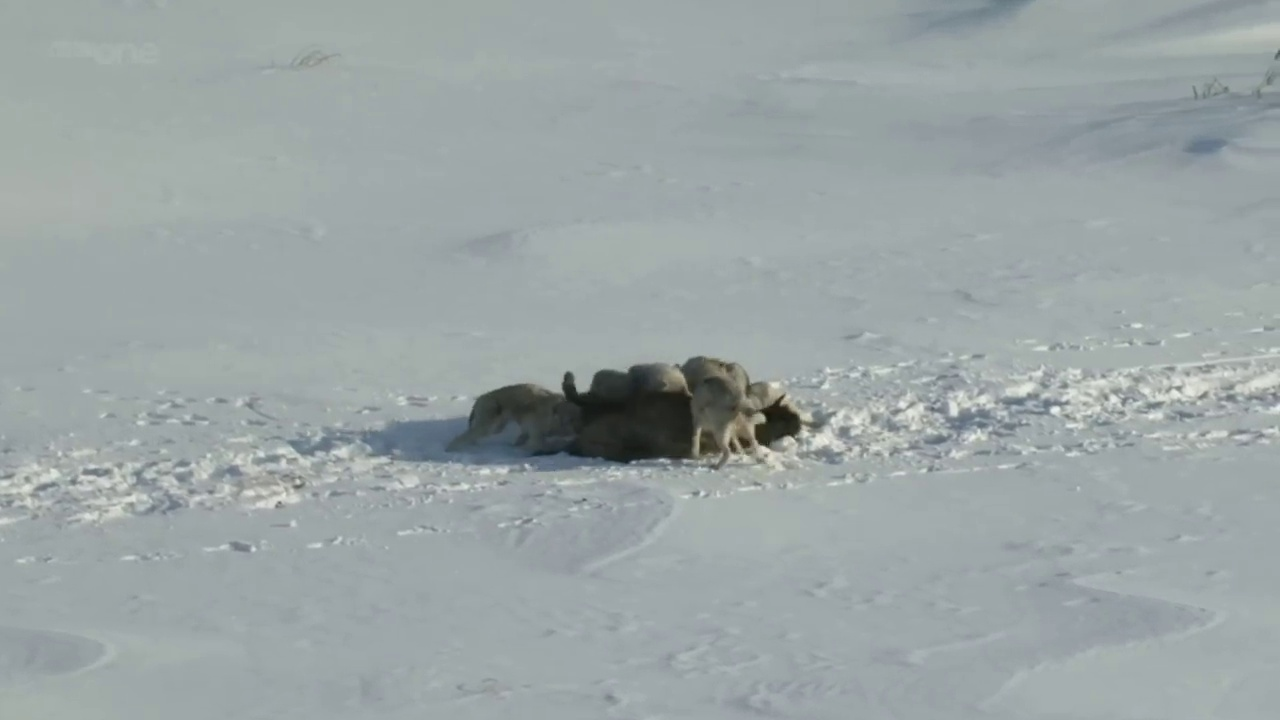

In [7]:
display_handle = display(None, display_id=True)
for img in base64Frames:
    display_handle.update(Image(data=base64.b64decode(img.encode("utf-8"))))
    time.sleep(0.025)

Once we have the video frames, we craft our prompt and send a request to GPT (Note that we don't need to send every frame for GPT to understand what's going on):


In [8]:
response = client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        "These are frames from a video that I want to upload. Generate a compelling description that I can upload along with the video."
                    )
                },
                *[
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{frame}"
                    }
                    for frame in base64Frames[0::25]
                ]
            ]
        }
    ],
)

print(response.output_text)

Witness an intense and gripping wildlife encounter in this dramatic footage captured in the snowy wilderness. A powerful bison is surrounded and relentlessly harassed by a fierce pack of wolves, showcasing the raw and ruthless struggle for survival in nature. Watch as the wolves coordinate their efforts, circling their massive prey, using strategy and teamwork to bring down the giant herbivore. This real-life predator-prey showdown is a stark reminder of the delicate balance of ecosystems and the primal instincts that drive the animal kingdom. Experience the thrilling drama of nature’s battle for life and death in this rare and captivating video.


## 2. Generating a voiceover for a video with GPT-4.1 and the GPT-4o TTS API


Let's create a voiceover for this video in the style of David Attenborough. Using the same video frames we prompt GPT to give us a short script:


In [9]:
result = client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        "These are frames of a video. Create a short voiceover script in the style of David Attenborough. Only include the narration."
                    )
                },
                *[
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{frame}"
                    }
                    for frame in base64Frames[0::25]
                ]
            ]
        }
    ]
)

print(result.output_text)

In the harsh winter plains, a formidable pack of wolves encircles a mighty bison. Their coordinated assault is a timeless tale of predator and prey — an intricate dance of survival. The bison resists, a wall of strength and endurance, but the wolves persist, their stamina unyielding. Around them, other bison watch cautiously, aware of the deadly drama unfolding. This is nature’s raw struggle, a testament to the relentless will to live in the wild.


Now, we can work with the GPT-4o TTS model and provide it a set of instructions on how the voice should sound. You can play around with the voice models and instructers at [OpenAI.fm](openai.fm). We can then pass in the script we generated above with GPT-4.1-mini and generate audio of the voiceover:


In [10]:
instructions = """
Voice Affect: Calm, measured, and warmly engaging; convey awe and quiet reverence for the natural world.

Tone: Inquisitive and insightful, with a gentle sense of wonder and deep respect for the subject matter.

Pacing: Even and steady, with slight lifts in rhythm when introducing a new species or unexpected behavior; natural pauses to allow the viewer to absorb visuals.

Emotion: Subtly emotive—imbued with curiosity, empathy, and admiration without becoming sentimental or overly dramatic.

Emphasis: Highlight scientific and descriptive language (“delicate wings shimmer in the sunlight,” “a symphony of unseen life,” “ancient rituals played out beneath the canopy”) to enrich imagery and understanding.

Pronunciation: Clear and articulate, with precise enunciation and slightly rounded vowels to ensure accessibility and authority.

Pauses: Insert thoughtful pauses before introducing key facts or transitions (“And then... with a sudden rustle...”), allowing space for anticipation and reflection.
"""

audio_response = response = client.audio.speech.create(
  model="gpt-4o-mini-tts",
  voice="echo",
  instructions=instructions,
  input=result.output_text,
  response_format="wav"
)

audio_bytes = audio_response.content
Audio(data=audio_bytes)